**Principal Component Analysis (PCA)**

(a) Overview: Principal Component Analysis (PCA) is a widely used dimensionality reduction technique that transforms a dataset with many correlated variables into a smaller set of uncorrelated variables called principal components. These components capture the most variance in the original data. PCA is eigenvalues and eigenvectors. Eigenvectors define the direction of the new feature space and determine the axes. Eigenvalues represent how much variance is in the data by each component. The first principal component (PC1) captures the direction of maximum variance in the dataset. The second principal component (PC2), orthogonal to the first, captures the next highest variance. Selecting the top few components reduce the dataset's dimensionality and retain most of its informative structure.

Dimensionality reduction is the process of simplifying a dataset by reducing the number of features. This is important when working with high-dimensional data for several reasons.One reason is improved visualization, reducing data to a few principal components enables visual exploration and better pattern recognition. Reducing noise is another important reason because high-dimensional data often contains irrelevant or redundant features. PCA filters out these less informative dimensions.
Using PCA maintains the structure integrity of the data  while making it more manageable for analysis, visualization, and modeling. This is useful in the study of population-level census microdata.



In [7]:
# Load Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import requests

API Call to ACS 5-Year PUMS

In [8]:
# API endpoint
url = "https://api.census.gov/data/2023/acs/acs5/pums"

# Valid PUMS variables for PCA
variables = "SEX,AGEP,SCHL,ESR,HINS1,PWGTP"

params = {
    "get": variables
}

# Make request
response = requests.get(url, params=params)

# Load into DataFrame
if response.status_code == 200:
    data = response.json()
    df = pd.DataFrame(data[1:], columns=data[0])
    print(" Data loaded successfully")
    display(df.head())
else:
    print(" Error:", response.status_code)
    print(response.text)


✅ Data loaded successfully


,SEX,AGEP,SCHL,ESR,HINS1,PWGTP
0,1,35,17,6,2,13
1,1,43,12,6,2,17
2,2,58,18,3,2,6
3,1,25,12,6,2,12
4,1,21,16,1,2,14


Step 4: Visualize the Data

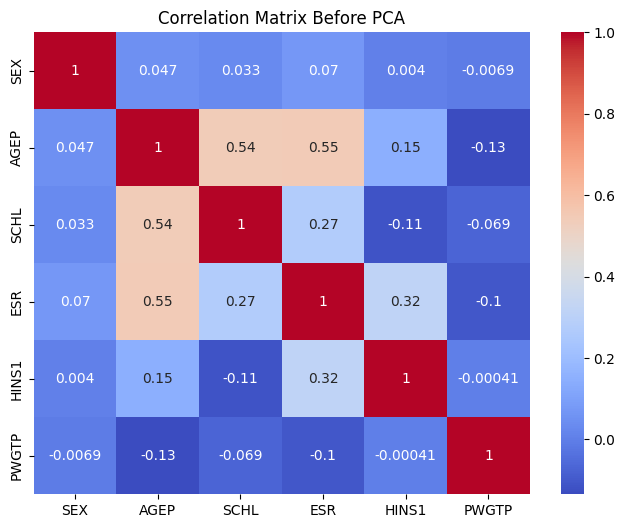

In [9]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix Before PCA")
plt.show()


Step 5: Standardize the Data

In [10]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)


Step 6: Apply PCA

In [11]:
pca = PCA(n_components=len(df.columns))
X_pca = pca.fit_transform(X_scaled)

# Explained variance
explained_var = pca.explained_variance_ratio_

# Create a DataFrame to summarize
pca_df = pd.DataFrame({
    'Principal Component': [f'PC{i+1}' for i in range(len(explained_var))],
    'Explained Variance Ratio': explained_var
})

display(pca_df)


,Principal Component,Explained Variance Ratio
0,PC1,0.333615
1,PC2,0.193639
2,PC3,0.165991
3,PC4,0.161184
4,PC5,0.086884
5,PC6,0.058687


Step 7: Visualize PCA Results
Scree Plot

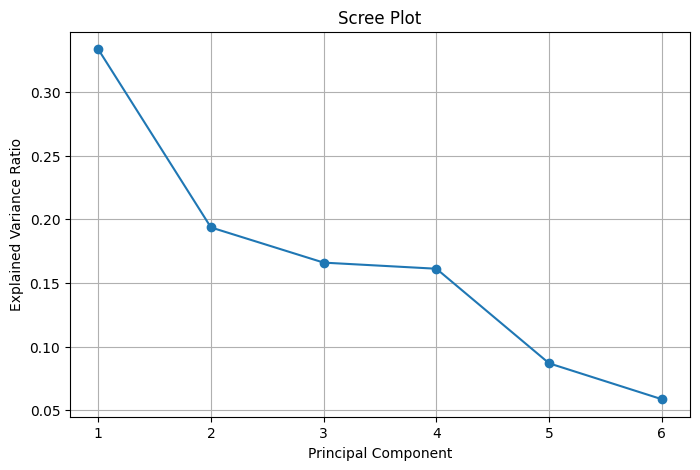

In [12]:
plt.figure(figsize=(8,5))
plt.plot(range(1, len(explained_var)+1), explained_var, marker='o')
plt.title('Scree Plot')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.grid(True)
plt.show()


2D PCA Projection

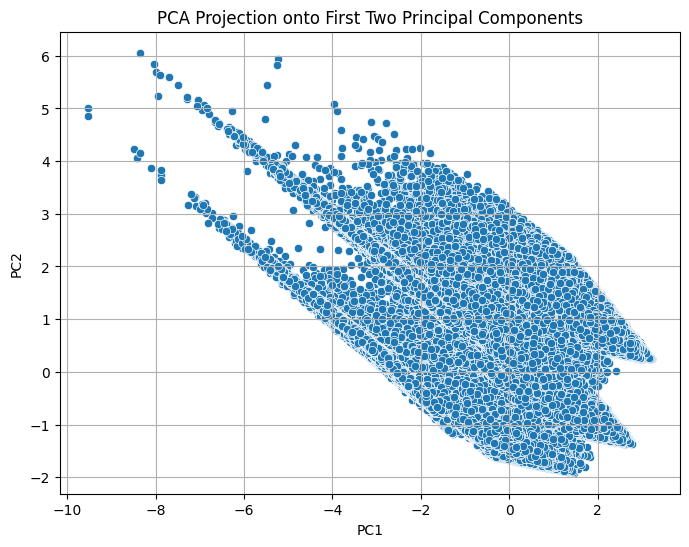

In [13]:
plt.figure(figsize=(8,6))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1])
plt.title("PCA Projection onto First Two Principal Components")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(True)
plt.show()


Save a Sample for GitHub

In [ ]:
# Save sample data
#df_sample = df.head(10)
#df_sample.to_csv("acs5_pums_pca_sample.csv", index=False)


**(d) Results:**
To better understand the structure of the census microdata, Principal Component Analysis was conducted on six numeric variables: SEX, AGEP, SCHL, ESR, HINS1, and PWGTP. Before applying PCA, visualization was used for correlation matrix, which revealed moderate correlations between variables like AGEP and ESR, as well as SCHL and AGEP. This indicated some redundancy in the features and justified the need for dimensionality reduction.

The scree plot of the explained variance ratio shows that the first two principal components together explain a large portion of the total variance, with diminishing returns for each additional component. This informed the decision to reduce the dataset to two principal components for visualization purposes.

The final scatterplot projects the dataset onto the first two principal components, revealing underlying patterns and groupings not easily visible in the raw high-dimensional data. This transformation simplifies the analysis and prepares the data for downstream tasks like clustering or classification, while preserving the majority of its variability.

**(e) Conclusions:**
Through Principal Component Analysis, the dimensionality of the census microdata was reduced while retaining variance in a few components. This transformation helped simplify the data and made it easier to identify relationships between demographic characteristics like age, education, employment status, and health insurance coverage. By reducing redundancy and noise in the data, PCA enhances the efficiency and accuracy of predictive models or methods applied later. It also enables clearer insights into the population structure, which can inform where and how to target future mental health resources based on key demographic drivers.